# 08 · Attention: 점수로 읽을 위치를 정하고 값을 섞기

**질문:** 모든 과거를 하나의 상태에 압축하는 대신, 현재 질문과 각 입력을 비교해서 필요한 정보를 읽을 수 있을까요?

Q·K·V → scaled dot-product → softmax 미분 → mask → 검색 학습을 구현합니다. 00의 행렬곱, 02의 softmax·CE, 03의 affine backward를 연결합니다. Attention 계산 부품을 먼저 완성하고, 다음 09에서 Transformer 구조로 조합합니다.

[그림 보조 파일](../../src/utils/architecture_plots.py) · [이전 LSTM·GRU](07_lstm_gru.ipynb) · [전체 경로](../../docs/CURRICULUM.md)

In [1]:
import sys
from pathlib import Path
project_root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src/utils/plotting.py").is_file())
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
import numpy as np
from src.utils import setup_plots
from src.utils.gradcheck import numerical_gradient, rel_error
from src.utils.architecture_plots import plot_matrices, plot_curves
setup_plots()
np.set_printoptions(precision=4, suppress=True)
print("NumPy", np.__version__, "· Attention 준비 완료")

NumPy 2.3.5 · Attention 준비 완료


## 1. Query, Key, Value는 서로 다른 역할입니다

도서 목록을 검색한다고 생각해 보세요. Q는 찾을 조건, K는 각 항목을 비교할 특징, V는 실제로 읽어 올 내용입니다. 실제 신경망에서는 이 배열을 선형 변환으로 만들고 그 가중치를 학습합니다.

| 배열 | shape | 축의 뜻 |
|---|---|---|
| Q | $(N,T_q,d_k)$ | 배치·질문 위치·비교 좌표 |
| K | $(N,T_k,d_k)$ | 배치·검색 대상 위치·비교 좌표 |
| V | $(N,T_k,d_v)$ | 배치·검색 대상 위치·내용 좌표 |
| S, P | $(N,T_q,T_k)$ | 질문별로 각 대상에 준 점수·가중치 |
| O | $(N,T_q,d_v)$ | 질문별 읽기 결과 |

$$S=QK^T/\sqrt{d_k},\quad P_{ij}=\frac{e^{S_{ij}}}{\sum_l e^{S_{il}}},\quad O=PV.$$

$K^T$는 배치 축을 유지하고 **마지막 두 축만** 뒤집습니다. 코드의 `swapaxes(-1,-2)`가 그 연산입니다. 3차원 배열의 `.T`는 모든 축을 역순으로 바꾸므로 여기서는 맞지 않습니다. `@`는 마지막 두 축의 행렬곱을 배치마다 수행합니다. softmax의 합은 항상 **key 축**인 마지막 축입니다.

먼저 질문 하나, key 두 개에서 점수가 `[log(3),0]`이면 가중치가 `[3/4,1/4]`가 되는 손계산을 구현합니다.

In [2]:
def attention_forward(Q, K, V, allowed=None):
    assert Q.ndim == K.ndim == V.ndim == 3
    assert Q.shape[0] == K.shape[0] == V.shape[0]
    assert Q.shape[-1] == K.shape[-1] and K.shape[1] == V.shape[1]
    scale = np.sqrt(Q.shape[-1])
    scores = (Q @ K.swapaxes(-1, -2)) / scale
    if allowed is None:
        mask = np.ones(scores.shape, dtype=bool)
    else:
        mask = np.broadcast_to(np.asarray(allowed, dtype=bool), scores.shape)
    if not np.all(mask.any(axis=-1)):
        raise ValueError("각 query에는 읽을 수 있는 key가 최소 하나 필요합니다")
    masked = np.where(mask, scores, -np.inf)
    shifted = masked - masked.max(axis=-1, keepdims=True)
    exp_scores = np.exp(shifted)
    P = exp_scores / exp_scores.sum(axis=-1, keepdims=True)
    O = P @ V
    return O, (Q, K, V, P, mask, scale)

In [3]:
Q_hand = np.array([[[np.sqrt(2) * np.log(3), 0.]]])
K_hand = np.eye(2)[None]
V_hand = np.array([[[10., 0.], [0., 20.]]])
O_hand, hand_cache = attention_forward(Q_hand, K_hand, V_hand)
np.testing.assert_allclose(hand_cache[3], [[[0.75, 0.25]]])
np.testing.assert_allclose(O_hand, [[[7.5, 5.]]])
print("가중치:", hand_cache[3], "· 읽은 값:", O_hand)

가중치: [[[0.75 0.25]]] · 읽은 값: [[[7.5 5. ]]]


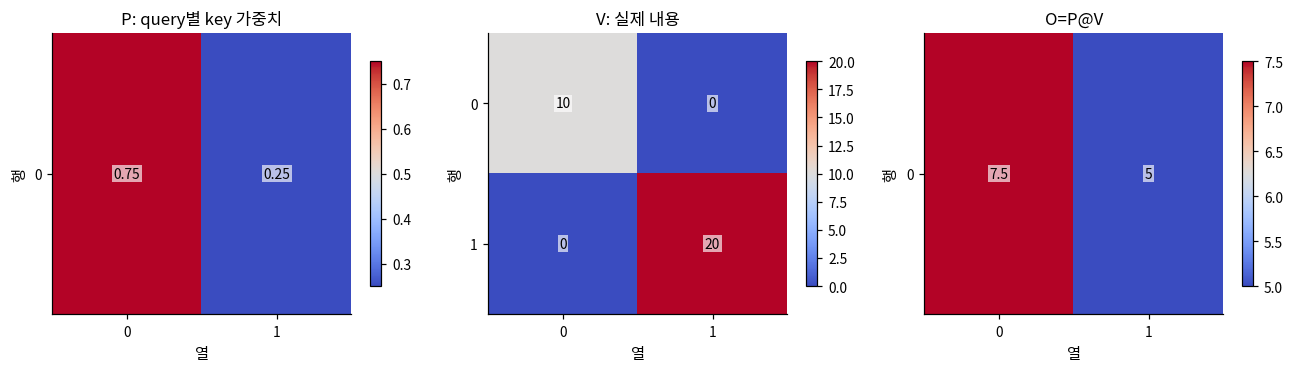

In [4]:
plot_matrices([hand_cache[3][0], V_hand[0], O_hand[0]],
              ["P: query별 key 가중치", "V: 실제 내용", "O=P@V"])

높은 가중치는 많이 읽었다는 계산상 의미입니다. 그것만으로 모델 판단의 인과적 설명이 증명되는 것은 아닙니다. K를 바꾸면 선택 비율이 달라지고, V를 바꾸면 같은 비율로 읽는 내용이 달라집니다.

## 2. 왜 $\sqrt{d_k}$로 나눕니까?

$q_i,k_i$가 서로 독립이고 평균 0·분산 1이라고 가정하면
$$\operatorname{Var}\left(\sum_{i=1}^{d_k}q_ik_i\right)=d_k.$$
곱의 평균은 0이고 $E[q_i^2k_i^2]=E[q_i^2]E[k_i^2]=1$입니다. 서로 다른 i의 교차항이 독립성으로 사라지므로 분산이 더해집니다. $\sqrt{d_k}$로 나누면 이 가정하의 분산이 1이 됩니다. 실제 학습된 Q·K가 항상 이 가정을 만족하는 것은 아닙니다.

지나치게 큰 점수 차이는 softmax를 한 위치에 몰리게 만들고, 많은 위치의 미분을 작게 만들 수 있습니다. 아래 실험은 분산 스케일만 확인합니다.

In [5]:
rng = np.random.default_rng(81)
dimensions = [2, 8, 32, 128]
raw_variance, scaled_variance = [], []
for d in dimensions:
    q, k = rng.normal(size=(10000, d)), rng.normal(size=(10000, d))
    dots = np.sum(q * k, axis=-1)
    raw_variance.append(np.var(dots))
    scaled_variance.append(np.var(dots / np.sqrt(d)))
print("스케일 후 경험적 분산:", np.array(scaled_variance))

스케일 후 경험적 분산: [0.9853 1.0227 1.0103 0.9876]


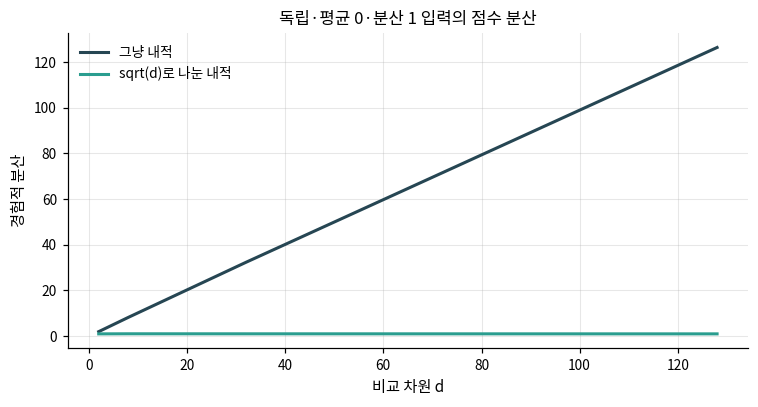

In [6]:
plot_curves(dimensions, {"그냥 내적": raw_variance, "sqrt(d)로 나눈 내적": scaled_variance},
            title="독립·평균 0·분산 1 입력의 점수 분산", xlabel="비교 차원 d", ylabel="경험적 분산")

## 3. Softmax backward는 원소별 미분만으로 끝나지 않습니다

한 행 $p=softmax(s)$에 대해
$$\frac{\partial p_i}{\partial s_j}=p_i(\delta_{ij}-p_j).$$
$\delta_{ij}$는 i=j이면 1, 아니면 0입니다. 분모를 모든 위치가 공유해서 $s_j$ 하나가 다른 확률에도 영향을 줍니다. 행렬 전체를 만들지 않고 상류 기울기 $g=\partial L/\partial p$와 곱하면
$$ds_j=p_j\left(g_j-\sum_i g_ip_i\right).$$

따라서 `P * (dP - (dP*P).sum(axis=-1, keepdims=True))`입니다. BCE에서 보았던 sigmoid의 `p*(1-p)`만 곱하면 경쟁하는 다른 위치의 기여를 빠뜨립니다.

Attention 전체는 다음 행렬 미분을 역순으로 연결합니다.
$$dV=P^TdO,\quad dP=dOV^T,$$
$$dS=P\odot\left(dP-\sum_{key}dP\odot P\right),$$
$$dQ=dSK/\sqrt{d_k},\qquad dK=dS^TQ/\sqrt{d_k}.$$

mask로 제외한 위치는 점수에 의존하지 않으므로 $dS=0$입니다. mask는 학습 파라미터가 아닌 고정된 연결 허용 규칙으로 다룹니다.

In [7]:
def softmax_backward(dP, P):
    return P * (dP - np.sum(dP * P, axis=-1, keepdims=True))


def attention_backward(dO, cache):
    Q, K, V, P, mask, scale = cache
    dV = P.swapaxes(-1, -2) @ dO
    dP = dO @ V.swapaxes(-1, -2)
    dS = np.where(mask, softmax_backward(dP, P), 0.)
    dQ = (dS @ K) / scale
    dK = (dS.swapaxes(-1, -2) @ Q) / scale
    return dQ, dK, dV


def check_attention_backward(candidate):
    rng = np.random.default_rng(82)
    errors = {}
    for masked in [False, True]:
        Q = rng.normal(size=(2, 2, 3))
        K = rng.normal(size=(2, 4, 3))
        V = rng.normal(size=(2, 4, 2))
        mask = np.array([[1, 1, 0, 0], [0, 1, 1, 1]], dtype=bool) if masked else None
        O, cache = attention_forward(Q, K, V, mask)
        G = rng.normal(size=O.shape)
        dQ, dK, dV = candidate(G, cache)
        scalar = lambda: float(np.sum(attention_forward(Q, K, V, mask)[0] * G))
        for name, value, grad in [("Q", Q, dQ), ("K", K, dK), ("V", V, dV)]:
            errors[f"mask={masked}/{name}"] = rel_error(grad, numerical_gradient(scalar, value))
            assert np.isfinite(errors[f"mask={masked}/{name}"]) and errors[f"mask={masked}/{name}"] < 2e-6, (masked, name, errors[f"mask={masked}/{name}"])
    return errors

In [8]:
np.testing.assert_allclose(softmax_backward(np.array([[2., -1.]]), np.array([[0.25, 0.75]])), [[9/16, -9/16]])
attention_errors = check_attention_backward(attention_backward)
print("Q·K·V와 mask 미분 최대 상대오차:", max(attention_errors.values()))

Q·K·V와 mask 미분 최대 상대오차: 5.101987596542411e-10


## 4. Mask: 읽을 수 있는 위치를 수식에 넣기

`allowed[q,k]=True`이면 질문 q가 key k를 읽을 수 있습니다. **causal mask**는 미래 k>q를 금지합니다. **padding mask**는 빈칸을 채우기 위해 덧붙인 가짜 key를 금지합니다. 둘은 목적이 다르며 필요한 경우 AND로 결합합니다.

softmax를 계산한 다음 가중치를 그냥 0으로 만들면 행 합이 1이 아니게 됩니다. 여기서는 금지 점수를 $-\infty$로 놓아 지수값을 0으로 만든 뒤 허용 위치 사이에서 정규화합니다. 한 행 전체를 금지하면 정규화할 확률분포가 없으므로 명시적으로 오류를 냅니다.

패딩 query 자체의 출력·손실을 제외하는 일은 key mask만으로 해결되지 않습니다. 다음 Transformer의 목적함수에서 유효 query도 별도로 정해야 합니다.

In [9]:
T = 4
causal = np.arange(T)[None, :] <= np.arange(T)[:, None]
valid_keys = np.array([True, True, True, False])
combined = causal & valid_keys[None, :]
Qm, Km, Vm = [rng.normal(size=(1, T, 3)) for _ in range(3)]
Om, cm = attention_forward(Qm, Km, Vm, combined)
np.testing.assert_allclose(cm[3].sum(axis=-1), 1.)
assert np.all(cm[3][0][~combined] == 0)
# 과거 출력 0·1은 미래 위치 2·3의 K·V를 바꾸어도 같습니다.
K_changed, V_changed = Km.copy(), Vm.copy()
K_changed[:, 2:] += 100
V_changed[:, 2:] -= 100
O_changed, _ = attention_forward(Qm, K_changed, V_changed, combined)
np.testing.assert_allclose(Om[:, :2], O_changed[:, :2], atol=1e-12)
try:
    attention_forward(Qm, Km, Vm, np.zeros((T, T), dtype=bool))
except ValueError as error:
    print("예상한 입력 거부:", error)
else:
    raise AssertionError("전부 금지된 행을 검출하지 못했습니다")

예상한 입력 거부: 각 query에는 읽을 수 있는 key가 최소 하나 필요합니다


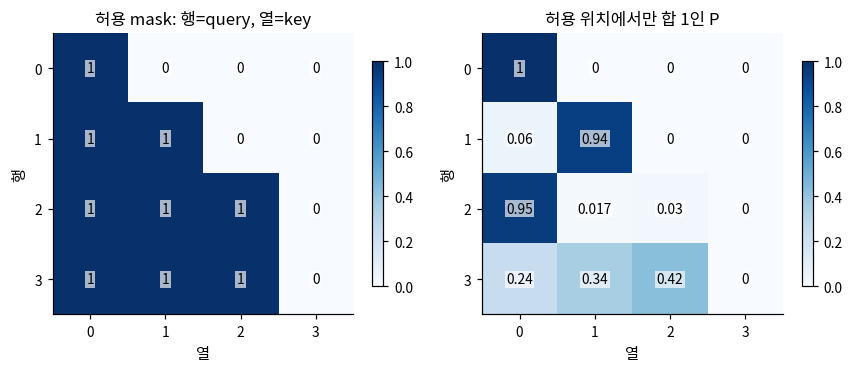

In [10]:
plot_matrices([combined.astype(int), cm[3][0]], ["허용 mask: 행=query, 열=key", "허용 위치에서만 합 1인 P"], cmap="Blues")

## 5. 완성 학습: key에 붙은 이진 값을 찾아 답하기

네 key의 정체는 one-hot 4차원으로 주어집니다. 각 key에는 매 예제마다 무작위 이진 값이 붙고, 행 순서도 섞입니다. query가 지정한 key의 값을 맞힙니다. key의 정체를 외워 일정한 답을 내면 값이 매번 바뀌기 때문에 해결할 수 없습니다.

학습 가능한 계산은
$$Q=X_qW_q,\quad K=X_kW_k,\quad O=Attention(Q,K,V),\quad z=O_0W_o+b.$$
이번 V는 데이터에 주어진 값의 one-hot `(N,4,2)`를 그대로 씁니다. 다음 Transformer에서는 V도 학습된 변환으로 만듭니다. $W_q,W_k$는 `(4,4)`, $W_o$는 `(2,2)`, logits는 `(N,2)`입니다.

CE의 $dz=(softmax(z)-onehot(y))/N$에서 head→attention→Q/K 변환으로 돌아갑니다. 위치별 affine의 파라미터 미분은 **배치와 위치를 함께 합한 것**이므로, 앞 두 축을 한 줄로 펼쳐 행렬곱합니다. 이는 평균을 새로 적용하는 연산이 아닙니다.

In [11]:
def retrieval_data(n, seed):
    rng = np.random.default_rng(seed)
    keys = np.empty((n, 4, 4))
    values = np.empty((n, 4, 2))
    queries = np.empty((n, 1, 4))
    labels = np.empty(n, dtype=int)
    for row in range(n):
        order = rng.permutation(4)
        bits = rng.integers(0, 2, size=4)
        query = rng.integers(4)
        keys[row] = np.eye(4)[order]
        values[row] = np.eye(2)[bits[order]]
        queries[row, 0] = np.eye(4)[query]
        labels[row] = bits[query]
    return queries, keys, values, labels


def ce_loss(logits, y):
    z = logits - logits.max(axis=1, keepdims=True)
    logp = z - np.log(np.exp(z).sum(axis=1, keepdims=True))
    grad = np.exp(logp)
    grad[np.arange(len(y)), y] -= 1
    return -logp[np.arange(len(y)), y].mean(), grad / len(y)


def retrieval_loss(Xq, Xk, V, y, p, backward_fn=attention_backward):
    Q, K = Xq @ p["Wq"], Xk @ p["Wk"]
    O, cache = attention_forward(Q, K, V)
    logits = O[:, 0] @ p["Wo"] + p["b"]
    loss, dz = ce_loss(logits, y)
    dO = (dz @ p["Wo"].T)[:, None, :]
    dQ, dK, dV = backward_fn(dO, cache)
    grads = {"Wo": O[:, 0].T @ dz, "b": dz.sum(axis=0),
             "Wq": Xq.reshape(-1, 4).T @ dQ.reshape(-1, 4),
             "Wk": Xk.reshape(-1, 4).T @ dK.reshape(-1, 4)}
    inputs = (dQ @ p["Wq"].T, dK @ p["Wk"].T, dV)
    return loss, logits, grads, cache[3], inputs


def adam_step(p, grads, state, step, lr=0.04):
    for key in p:
        m, v = state[key]
        m = 0.9 * m + 0.1 * grads[key]
        v = 0.999 * v + 0.001 * grads[key] ** 2
        p[key] -= lr * (m / (1 - 0.9 ** step)) / (np.sqrt(v / (1 - 0.999 ** step)) + 1e-8)
        state[key] = (m, v)


def init_retrieval(seed=85):
    rng = np.random.default_rng(seed)
    return {"Wq": rng.normal(size=(4, 4)) * 0.5, "Wk": rng.normal(size=(4, 4)) * 0.5,
            "Wo": rng.normal(size=(2, 2)) * 0.7, "b": np.zeros(2)}

In [12]:
probe_data = retrieval_data(2, 84)
probe_p = init_retrieval()
loss, _, grads, _, input_grads = retrieval_loss(*probe_data, probe_p)
scalar = lambda: float(retrieval_loss(*probe_data, probe_p)[0])
model_errors = {k: rel_error(grads[k], numerical_gradient(scalar, v)) for k, v in probe_p.items()}
for name, value, grad in zip(["Xq", "Xk", "V"], probe_data[:3], input_grads):
    model_errors[name] = rel_error(grad, numerical_gradient(scalar, value))
assert max(model_errors.values()) < 2e-6
print("검색 모델 전체 미분 최대 상대오차:", max(model_errors.values()))

검색 모델 전체 미분 최대 상대오차: 2.966572677205445e-08


In [13]:
train = retrieval_data(256, 86)
valid = retrieval_data(128, 87)
p = init_retrieval()
state = {k: (np.zeros_like(v), np.zeros_like(v)) for k, v in p.items()}
_, _, _, before_weights, _ = retrieval_loss(*valid, p)
history = {"step": [], "train": [], "valid": []}
for step in range(501):
    loss, logits, grads, _, _ = retrieval_loss(*train, p)
    if step % 50 == 0:
        valid_loss, valid_logits, _, after_weights, _ = retrieval_loss(*valid, p)
        history["step"].append(step)
        history["train"].append(loss)
        history["valid"].append(valid_loss)
    if step == 500:
        break
    adam_step(p, grads, state, step + 1)
accuracy = np.mean(valid_logits.argmax(axis=1) == valid[-1])
print(f"학습 CE {history['train'][0]:.6f} → {history['train'][-1]:.6f}")
print(f"검증 CE {history['valid'][-1]:.6f} · 정확도 {accuracy:.1%} (n=128)")
print("예시 query 정체:", valid[0][:4, 0].argmax(axis=-1), "· 행별 key 정체:", valid[1][:4].argmax(axis=-1))
assert accuracy > 0.95 and history["train"][-1] < 0.1

학습 CE 0.680324 → 0.001135
검증 CE 0.001138 · 정확도 100.0% (n=128)
예시 query 정체: [1 2 0 2] · 행별 key 정체: [[1 3 2 0]
 [1 2 0 3]
 [1 0 3 2]
 [0 1 2 3]]


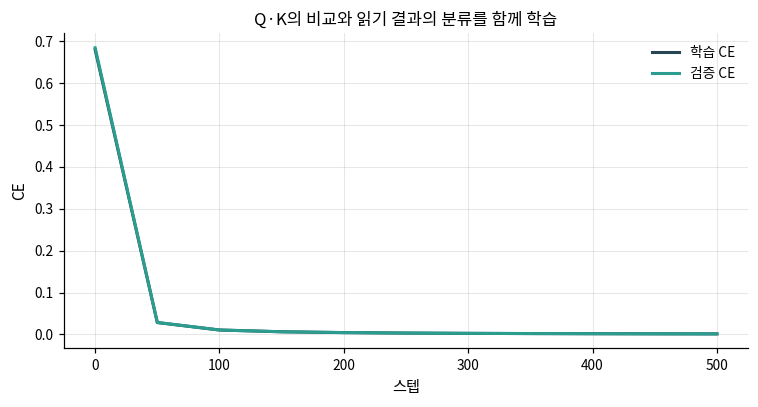

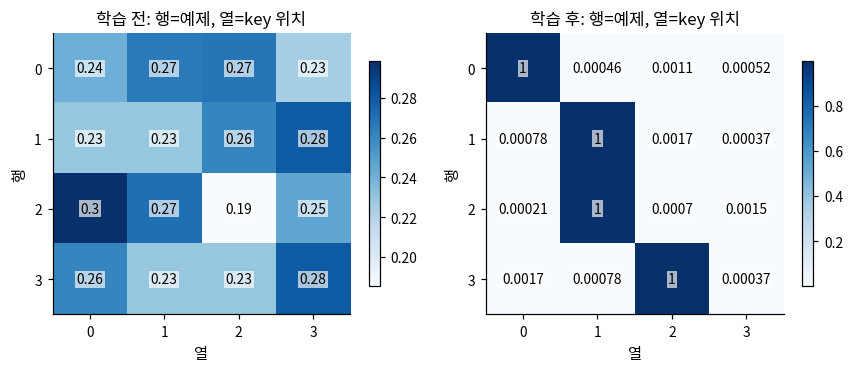

In [14]:
plot_curves(history["step"], {"학습 CE": history["train"], "검증 CE": history["valid"]},
            title="Q·K의 비교와 읽기 결과의 분류를 함께 학습", ylabel="CE")
plot_matrices([before_weights[:4, 0], after_weights[:4, 0]],
              ["학습 전: 행=예제, 열=key 위치", "학습 후: 행=예제, 열=key 위치"], cmap="Blues")

가중치 그림과 출력한 key 정체를 함께 읽으세요. 높은 가중치가 query와 같은 정체의 key 위치에 놓이는지 확인할 수 있습니다. 학습·검증은 같은 유한 생성 규칙에서 별도 추출했으며 일부 key/값 조합이 겹칠 수 있습니다. 이 결과는 작은 검색 규칙의 학습 확인입니다.

## 6. Self-attention과 cross-attention, 그리고 순서

Q의 원천과 K·V의 원천이 같은 시퀀스이면 **self-attention**, 서로 다르면 **cross-attention**입니다. Q·K·V의 값이나 가중치가 모두 같다는 뜻은 아닙니다. 이번 검색 문제는 질문과 목록이 다른 원천이므로 cross-attention입니다.

위치 정보·mask가 없는 상태에서 K·V의 행을 **함께** 재배열하면 읽기 결과는 같습니다. 항목을 다른 순서로 나열했을 뿐이기 때문입니다. 순서가 의미 있는 언어 문제에서는 이 성질만으로 충분하지 않아 위치 정보를 넣습니다.

In [15]:
Q = valid[0] @ p["Wq"]
K = valid[1] @ p["Wk"]
V = valid[2]
permutation = np.array([2, 0, 3, 1])
original, _ = attention_forward(Q, K, V)
reordered, _ = attention_forward(Q, K[:, permutation], V[:, permutation])
np.testing.assert_allclose(original, reordered, atol=1e-12)
print("K·V의 공동 순열에 대한 출력 불변 검산 통과")

K·V의 공동 순열에 대한 출력 불변 검산 통과


## 7. 직접 변형하고 검사하기

1. `my_attention_backward(dO, cache)`를 새 셀에 작성하고 `check_attention_backward(my_attention_backward)`를 실행하세요. query 길이 2, key 길이 4, 값 차원 2와 비교 차원 3을 섞지 않아야 합니다.
2. padding mask와 causal mask를 각각 바꾸고 **허용 위치에서의 행 합=1, 금지 위치=0, 미래 변경에 대한 과거 출력 유지**를 확인하세요. 모두 금지된 query 행은 어떻게 처리해야 합니까?
3. key 수를 4→3으로 바꿀 때 one-hot 차원, Wq·Wk, 데이터 생성과 reshape의 숫자를 먼저 적으세요. query 수가 2개라면 출력과 라벨·손실 평균 축은 어떻게 확장되어야 합니까?

아래 오답은 softmax를 sigmoid처럼 원소별로만 미분합니다. 실제 후보를 검사기에 넣어 거부되는 것을 확인합니다.

In [16]:
def wrong_elementwise_softmax(dO, cache):
    Q, K, V, P, mask, scale = cache
    dP = dO @ V.swapaxes(-1, -2)
    dS = dP * P * (1 - P)
    return (dS @ K) / scale, (dS.swapaxes(-1, -2) @ Q) / scale, P.swapaxes(-1, -2) @ dO

In [17]:
try:
    check_attention_backward(wrong_elementwise_softmax)
except AssertionError:
    print("의도적 오답 검출: softmax의 다른 위치 기여 누락")
else:
    raise AssertionError("검사기가 오답을 놓쳤습니다")

의도적 오답 검출: softmax의 다른 위치 기여 누락


### 준비도 확인

- **설명:** Q·K·V의 역할과 self/cross의 차이를 구분할 수 있습니까?
- **수식:** softmax의 전체 분모를 미분하고 Q·K·V로 돌아가는 식을 쓸 수 있습니까?
- **구현:** 마지막 두 축의 전치·배치 행렬곱·key 축 정규화를 맞출 수 있습니까?
- **변형:** 직사각형 attention과 mask를 처리하고, 위치가 없을 때의 순열 성질을 검산할 수 있습니까?

[Transformer 원 논문의 3.2절](https://arxiv.org/abs/1706.03762)에 scaled dot-product attention과 여러 head의 결합이 정의되어 있습니다. 이 노트북은 하나의 head를 독립적으로 구현했습니다.

다음은 [09 Transformer](09_transformer.ipynb)입니다.